# 30 · E1q: the cheapest slow model — is "wiring + one slow process" enough?

**Where Notebook 29 left off.** Converged, the ladder splits in two:

| held-out FEVE (both strains) | L0 | `L1c` | `L0w` | L1 | **L1s** | L2 | L3 | L4 | B |
|---|---|---|---|---|---|---|---|---|---|
| | 0.428 | 0.432 | 0.429 | 0.447 | **0.488** | 0.473 | 0.472 | 0.483 | 0.322 |

* **Every rung with a slow process beats L0 by 0.04–0.06, and nothing without one does.** The slow rungs are L1s (slow leak current), L2 (adaptation), L3 (peptides) and L4 (homeostasis).
* E1's three rules choose **L1s**: L1 plus one global slow current, two numbers.
* The black box is far behind.

**The cheapest slow models were missing.** L1s carries L1's per-synapse weights and sigmoid neurons, and Notebook 28 showed that *without* a slow process neither of these helps. So the slow process may be all that matters:

| | no slow process | + one global slow current (ρ, τ_n) |
|---|---|---|
| linear, class weights | L0 (126 params) | **`L0s`** (128) |
| sigmoid, class weights | `L1c` (345) | **`L1cs`** (347, new in package 0.25) |
| sigmoid, per-synapse weights | L1 (1124) | L1s (1126) |

This notebook fits `L0s` and `L1cs` exactly as Notebook 29 fitted L1s:
* `L0s` starts from the converged L0, and `L1cs` from the converged `L1c`, each with the slow current at ρ = 0.1, τ_n = 10 s;
* both are fitted to convergence by warm-restarted cycles on the same inner split.

They are then added to Notebook 29's converged ladder and E1's rules are applied once more.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 25, 0), \
    f"Notebook 30 needs closurebench >= 0.25.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BOOT, THRESHOLD, VAL_FRAC = 2000, 0.05, 0.2
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG
PRIOR = "laptop" if MODE == "smoke" else MODE
NEW = ("L0s", "L1cs")
CYC = {"smoke": dict(CYCLE_STEPS=30, MAX_CYCLES=3, EVAL_EVERY=10, PATIENCE=2, TOL=1e-3),
       "laptop": dict(CYCLE_STEPS=1000, MAX_CYCLES=6, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3),
       "full": dict(CYCLE_STEPS=1500, MAX_CYCLES=8, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3)}[MODE]; globals().update(CYC)
SLOW_START = (0.1, 10.0)                                     # as for L1s in Notebook 29

def to_np(p):
    q = jax.tree_util.tree_map(np.asarray, dict(p))
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q
def to_jnp(p):
    q = {k: (v if k == "n_heads" else jax.tree_util.tree_map(jnp.asarray, v)) for k, v in dict(p).items()}
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q

try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    c = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"]); LR = float(c.get("lr", 1e-2))
    ck28, ck29 = os.path.join(RESULTS, "e1o_ck", PRIOR), os.path.join(RESULTS, "e1p_ck", PRIOR)
    def _converged(f, L):                                    # Notebook 29's extra cycles if any, else Notebook 28's fit
        for pth in (os.path.join(ck29, f"fold{f}_{L}_more.pkl"), os.path.join(ck28, f"fold{f}_{L}.pkl")):
            if os.path.exists(pth): return to_np(pickle.load(open(pth, "rb"))["params"])
        raise FileNotFoundError(f"no converged {L} for fold {f}")
    BASE = [{L: _converged(f, L) for L in ("L0", "L1c")} for f in range(len(folds))]
    P29 = dict(np.load(os.path.join(RESULTS, f"E1p_heldout_predictions{E1_TAG}.npz")))
    d9 = os.path.join(RESULTS, f"E1e_result{E1_TAG}.json")
    DELTA = json.load(open(d9))["delta"] if os.path.exists(d9) else {}
    SOURCE = f"E1 ({E1_TAG.strip('_') or 'full'}) data and folds; converged L0 / L1c (Notebooks 28-29); Notebook 29's ladder"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("Notebook 29 results not found (", err, ") -> CODE-PATH TEST ONLY on a synthetic worm")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=24, S=10, seed=1), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = M_.kfold_pairs(ds, 2, 0); LR = 1e-2
    BASE = P29 = None; DELTA = {"repeat": 0.01}; SOURCE = "synthetic (code path only)"
print(f"source: {SOURCE} | {ds.N} neurons, {ds.S} stimuli | {len(folds)} folds | lr {LR} | {CYC}")

source: E1 (laptop) data and folds; converged L0 / L1c (Notebooks 28-29); Notebook 29's ladder | 120 neurons, 120 stimuli | 5 folds | lr 0.02 | {'CYCLE_STEPS': 1000, 'MAX_CYCLES': 6, 'EVAL_EVERY': 100, 'PATIENCE': 5, 'TOL': 0.001}


### Pre-registration (before §1)

Recorded in `results/E1q_preregistration*.json`. Folds, inner split, metric and bootstrap are as in Notebooks 28–29.

**Fits.** On the inner-training pairs, `ladder.fit_cycles` with Notebook 29's settings:
* `L0s` starts from the converged L0;
* `L1cs` starts from the converged `L1c`;
* both start with ρ = 0.1, τ_n = 10 s (Notebook 29's start for L1s).

**Rules.** Held-out FEVE on the outer test pairs, both strains, 95 % bootstrap CI. Notebook 29's held-out predictions are used for every other rung.
* **SLOW_HELPS_LINEAR:** `L0s` − L0, CI lower bound > 0.
* **SLOW_HELPS_COMPACT:** `L1cs` − `L1c`, CI lower bound > 0.
* **CHEAPEST_SLOW** (primary): the model with the fewest parameters among `L0s`, `L1cs`, L1s that is *not significantly worse* than L1s, i.e. the CI upper bound of (model − L1s) ≥ 0.
* **CLOSED_FINAL:** sufficiency, necessity and v4 (every δ) on the complete ladder ordered by free parameters (L0, `L0s`, `L1c`, `L1cs`, `L0w`, L1, L1s, L2, L3, L4), both strains and WT, with the black-box rule.

**Reported:**
* the fitted ρ and τ_n;
* each slow model's inner validation loss against its parent's (the Notebook 29 caveat);
* WT and unc-31.

In [3]:
prereg = os.path.join(RESULTS, f"E1q_preregistration{TAG}.json")
plan = {"experiment": "E1q cheapest slow model: L0s (from converged L0), L1cs (from converged L1c), fit_cycles; complete converged ladder",
        "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "source": SOURCE,
        "cycles": CYC, "slow_start": SLOW_START, "n_boot": N_BOOT,
        "SLOW_HELPS_LINEAR": "L0s - L0, CI lower bound > 0", "SLOW_HELPS_COMPACT": "L1cs - L1c, CI lower bound > 0",
        "CHEAPEST_SLOW": "fewest-parameter model among L0s, L1cs, L1s whose (model - L1s) CI upper bound >= 0",
        "CLOSED_FINAL": "sufficiency, necessity, v4 on L0, L0s, L1c, L1cs, L0w, L1, L1s, L2, L3, L4 by parameters; black-box rule"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1q_preregistration_laptop.json


## 1 · Converge `L0s` and `L1cs` (checkpointed)

`laptop` mode: `L0s` takes about 5 min per fold and `L1cs` about 10, so roughly 1–1.5 h in total.

In [4]:
CK = os.path.join(RESULTS, "e1q_ck", MODE); os.makedirs(CK, exist_ok=True)
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def inner(f):
    train = split(f)[0] & ds.mask()
    u = np.random.default_rng(100 + f).random(ds.mask().shape[1:]) < VAL_FRAC
    val = train & np.broadcast_to(u, train.shape)
    return train & ~val, val
def cyc_fit(f, name, L, init):
    pth = os.path.join(CK, f"fold{f}_{name}.pkl")
    if os.path.exists(pth):
        d = pickle.load(open(pth, "rb")); return d["params"], d["info"]
    itr, val = inner(f); t0 = time.time()
    p, info = lad.fit_cycles(L, ds, None if init is None else to_jnp(init), itr, val, steps=CYCLE_STEPS, max_cycles=MAX_CYCLES,
                             tol=TOL, eval_every=EVAL_EVERY, patience=PATIENCE, lr=LR, st=st, cfg=cfg, seed=f)
    info = dict(info, seconds=time.time() - t0); p = to_np(p)
    pickle.dump({"params": p, "info": info}, open(pth, "wb"))
    vs = [info["cycles"][0]["val_start"]] + [c_["val_best"] for c_ in info["cycles"] if c_["accepted"]]
    print(f"fold {f} {name:5s}: {info['n_accepted']} accepted cycle(s), {'converged' if info['converged'] else 'MAX_CYCLES reached'} | "
          f"validation loss " + " -> ".join(f"{v:.4f}" for v in vs) + f" | {info['seconds'] / 60:.1f} min", flush=True)
    return p, info
def with_slow(p, L, rho, tau_n):
    q = lad.extend_params(to_jnp(p), L, st, jax.random.PRNGKey(0))
    q["rho_s"] = jnp.array(float(np.log(rho / (0.9 - rho)))); q["tau_ns"] = jnp.array(lad.inv_sp(max(tau_n - lad.TAU_MIN, 0.05)))
    return to_np(q)
def val_loss(f, L, p):
    """Inner validation loss of a fitted model (the quantity fit_cycles compares)."""
    itr, val = inner(f)
    _, _ = lad.fit(L, ds, train_mask=itr, val_mask=val, init=to_jnp(p), steps=1, eval_every=1, patience=1, lr=0.0, verbose=0, st=st, cfg=cfg)
    return lad.LAST_EARLY_STOP["val_start"]
if BASE is None:                                             # smoke: quick clean parents and a quick stand-in ladder
    BASE, P29 = [], None
    for f in range(len(folds)):
        itr, val = inner(f)
        BASE.append({L: cyc_fit(f, f"{L}_parent", L, None)[0] for L in ("L0", "L1c")})
FITS, INFO, VAL = [], {}, {}
for f in range(len(folds)):
    FITS.append({})
    for L, parent in (("L0s", "L0"), ("L1cs", "L1c")):
        FITS[f][L], INFO[(f, L)] = cyc_fit(f, L, L, with_slow(BASE[f][parent], L, *SLOW_START))
        VAL[(f, L)] = (val_loss(f, parent, BASE[f][parent]), INFO[(f, L)]["val_best"])
for L, parent in (("L0s", "L0"), ("L1cs", "L1c")):
    rho = [0.9 / (1 + np.exp(-float(FITS[f][L]["rho_s"]))) for f in range(len(folds))]
    tau = [lad.TAU_MIN + float(np.log1p(np.exp(FITS[f][L]["tau_ns"]))) for f in range(len(folds))]
    print(f"{L}: rho {np.round(rho, 3)} | tau_n {np.round(tau, 1)} s | inner validation loss {parent} -> {L}: "
          + ", ".join(f"{VAL[(f, L)][0]:.4f}->{VAL[(f, L)][1]:.4f}" for f in range(len(folds))))

fold 0 L0s  : 1 accepted cycle(s), converged | validation loss 1.1000 -> 0.8574 | 2.5 min
fold 0 L1cs : 1 accepted cycle(s), converged | validation loss 0.8898 -> 0.8576 | 3.1 min
fold 1 L0s  : 1 accepted cycle(s), converged | validation loss 0.9878 -> 0.8534 | 1.8 min
fold 1 L1cs : 1 accepted cycle(s), converged | validation loss 0.8953 -> 0.8687 | 3.0 min
fold 2 L0s  : 1 accepted cycle(s), converged | validation loss 0.9015 -> 0.8414 | 1.9 min
fold 2 L1cs : 1 accepted cycle(s), converged | validation loss 0.9262 -> 0.8337 | 2.6 min
fold 3 L0s  : 1 accepted cycle(s), converged | validation loss 0.9754 -> 0.8745 | 2.5 min
fold 3 L1cs : 1 accepted cycle(s), converged | validation loss 0.8879 -> 0.8697 | 2.8 min
fold 4 L0s  : 1 accepted cycle(s), converged | validation loss 1.0131 -> 0.8799 | 2.4 min
fold 4 L1cs : 1 accepted cycle(s), converged | validation loss 0.8956 -> 0.8821 | 2.2 min
L0s: rho [0.095 0.096 0.096 0.103 0.103] | tau_n [10. 10. 10. 10. 10.] s | inner validation loss L0 

## 2 · The complete converged ladder

rung   params    both      WT  unc-31
L0        126   0.428   0.381   0.529
L0s       128   0.440   0.390   0.546
L1c       345   0.432   0.396   0.509
L1cs      347   0.437   0.398   0.522
L0w       982   0.429   0.382   0.529
L1       1124   0.447   0.407   0.532
L1s      1126   0.488   0.434   0.604
L2       1417   0.473   0.420   0.586
L3       1564   0.472   0.435   0.549
L4       1711   0.483   0.450   0.555
B           —   0.322   0.351   0.259

  L0s-L0    : +0.0119  95% CI [+0.0067, +0.0192]
  L1cs-L1c  : +0.0055  95% CI [-0.0003, +0.0116]
  L0s-L1s   : -0.0483  95% CI [-0.0790, -0.0275]
  L1cs-L1s  : -0.0509  95% CI [-0.0738, -0.0341]
  L1cs-L0s  : -0.0025  95% CI [-0.0226, +0.0193]
  L1s-L0    : +0.0602  95% CI [+0.0372, +0.0952]

rung   gain over best shallower rung [95% CI]   needed?
L0s    +0.012 [+0.007, +0.019]               yes
L1c    -0.007 [-0.031, +0.016]               no
L1cs   -0.004 [-0.023, +0.008]               no
L0w    -0.015 [-0.033, -0.007]               no

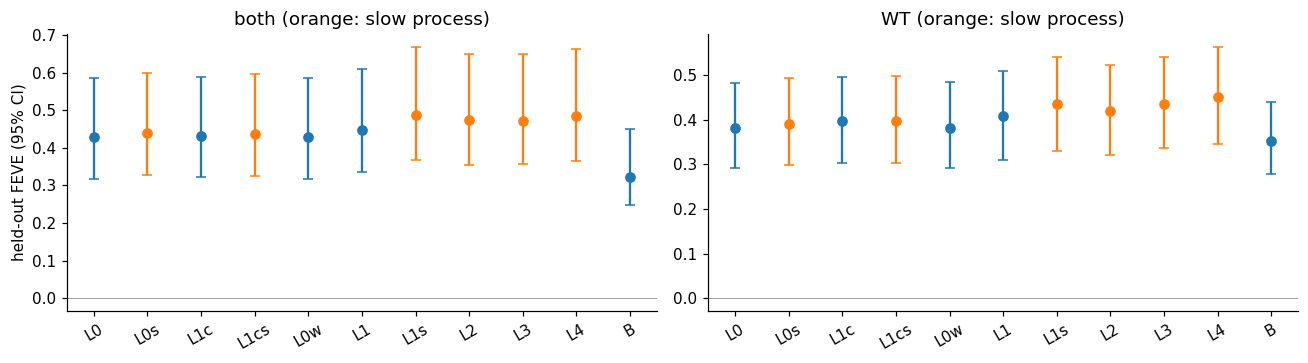

In [5]:
def full_pred(L, p):
    cols = np.arange(ds.S)
    return np.asarray(lad.predict(L, to_jnp(p), st, ds.stim, ds.strains, cfg, cols, proto=lad.proto_cols(ds, cols)))
def cv_from(models, L):
    out = np.zeros(ds.mean.shape)
    for f in range(len(folds)):
        msk = folds[f].reshape(folds[f].shape + (1,) * (ds.mean.ndim - 3))
        out = np.where(msk, full_pred(L, models[f][L]), out)
    return out
PRED = {L: cv_from(FITS, L) for L in NEW}
if P29 is not None:
    PRED.update(P29)
else:                                                         # smoke: the parents and a quick L1s / B stand in for Notebook 29
    PRED.update({L: cv_from(BASE, L) for L in ("L0", "L1c")})
    QUICK = [{L: cyc_fit(f, f"{L}_quick", L, None)[0] for L in ("L1s", "B")} for f in range(len(folds))]
    PRED.update({L: cv_from(QUICK, L) for L in ("L1s", "B")})
ALL = [L for L in ("L0", "L0s", "L1c", "L1cs", "L0w", "L1", "L1s", "L2", "L3", "L4") if L in PRED]
COUNT = {L: lad.trainable_count(L, st) for L in ALL}
LADDER = tuple(sorted(ALL, key=COUNT.get))
def decide(strain=None):
    point, boots = M_.bootstrap_feve(PRED, ds, list(LADDER) + ["B"], n_boot=N_BOOT, seed=0, strain=strain)
    suff = M_.closure_decision(point, boots, ladder=LADDER, threshold=THRESHOLD, blackbox="B")
    nec = M_.necessity(point, boots, ladder=LADDER)
    v4 = {"delta=0": M_.calibrated_closure(boots, 0.0, LADDER)["L_closed"]}
    v4.update({f"delta[{k}]={d:.3f}": M_.calibrated_closure(boots, d, LADDER)["L_closed"] for k, d in DELTA.items()})
    return dict(point=point, boots=boots, L_star=suff["L_star"], L_needed=nec["L_needed"], v4=v4, nec=nec)
RES = {"both": decide(), "WT": decide("wt")}
per_u = M_.bootstrap_feve(PRED, ds, list(LADDER) + ["B"], n_boot=200, seed=0, strain="unc31")[0] if "unc31" in ds.strains else {}
print(f"{'rung':5s}{'params':>8s}{'both':>8s}{'WT':>8s}{'unc-31':>8s}")
for L in LADDER + ("B",):
    print(f"{L:5s}{str(COUNT.get(L, '—')):>8s}{RES['both']['point'][L]:8.3f}{RES['WT']['point'][L]:8.3f}{per_u.get(L, np.nan):8.3f}")
b, pt = RES["both"]["boots"], RES["both"]["point"]
def contrast(x, y):
    d = b[x] - b[y]; lo, hi = np.percentile(d, [2.5, 97.5]); return float(pt[x] - pt[y]), [float(lo), float(hi)]
TESTS = {f"{x}-{y}": contrast(x, y) for x, y in (("L0s", "L0"), ("L1cs", "L1c"), ("L0s", "L1s"), ("L1cs", "L1s"), ("L1cs", "L0s"), ("L1s", "L0"))
         if x in PRED and y in PRED}
print()
for k, (m, ci) in TESTS.items():
    print(f"  {k:10s}: {m:+.4f}  95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}]")
SLOW_HELPS_LINEAR = TESTS["L0s-L0"][1][0] > 0
SLOW_HELPS_COMPACT = TESTS["L1cs-L1c"][1][0] > 0
cands = [L for L in ("L0s", "L1cs", "L1s") if L in PRED]
ok = [L for L in cands if L == "L1s" or TESTS[f"{L}-L1s"][1][1] >= 0]
CHEAPEST_SLOW = min(ok, key=COUNT.get)
print(); print(M_.format_necessity(RES["both"]["nec"]))
for k, r in RES.items():
    print(f"{k:5s}: L* = {r['L_star']} | L_needed = {r['L_needed']} | v4 = {r['v4']}")
OC = {}
for k in ("both", "WT"):
    r = RES[k]; Ls = r["L_star"]
    if Ls is None:
        OC[k] = False; continue
    lo, hi = np.percentile(r["boots"]["B"] - r["boots"][Ls], [2.5, 97.5]); OC[k] = bool(lo > THRESHOLD)
    print(f"black box ({k}): FEVE(B) - FEVE({Ls}) = {r['point']['B'] - r['point'][Ls]:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
print("Registered rules -> SLOW_HELPS_LINEAR:", SLOW_HELPS_LINEAR, "| SLOW_HELPS_COMPACT:", SLOW_HELPS_COMPACT,
      "| CHEAPEST_SLOW:", CHEAPEST_SLOW, "| OUTCOME_C (both / WT):", OC.get("both"), "/", OC.get("WT"))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for a, k in ((ax[0], "both"), (ax[1], "WT")):
    r = RES[k]; lab = list(LADDER) + ["B"]
    mu = [r["point"][L] for L in lab]; lo = [np.percentile(r["boots"][L], 2.5) for L in lab]; hi = [np.percentile(r["boots"][L], 97.5) for L in lab]
    cols_ = ["C1" if L in ("L0s", "L1cs", "L1s", "L2", "L3", "L4") else "C0" for L in lab]
    for i_, (m_, l_, h_, c_) in enumerate(zip(mu, lo, hi, cols_)):
        a.errorbar([i_], [m_], yerr=[[m_ - l_], [h_ - m_]], fmt="o", capsize=3, color=c_)
    a.set_xticks(range(len(lab))); a.set_xticklabels(lab, rotation=30); a.set_title(f"{k} (orange: slow process)"); a.axhline(0, c="0.6", lw=0.6)
ax[0].set_ylabel("held-out FEVE (95% CI)"); plt.tight_layout(); plt.show()

In [6]:
out = {"source": SOURCE, "cycles": CYC, "slow_start": SLOW_START, "free_parameters": COUNT, "ladder": list(LADDER),
       "SLOW_HELPS_LINEAR": bool(SLOW_HELPS_LINEAR), "SLOW_HELPS_COMPACT": bool(SLOW_HELPS_COMPACT), "CHEAPEST_SLOW": CHEAPEST_SLOW,
       "tests": TESTS, "OUTCOME_C": OC,
       "decisions": {k: {"feve": {L: float(v) for L, v in r["point"].items()}, "L_star": r["L_star"], "L_needed": r["L_needed"], "v4": r["v4"]}
                     for k, r in RES.items()},
       "feve_unc31": {L: float(v) for L, v in per_u.items()},
       "inner_val_parent_vs_slow": {f"{f}/{L}": VAL[(f, L)] for f in range(len(folds)) for L in NEW},
       "fits": {f"{f}/{L}": INFO[(f, L)] for f in range(len(folds)) for L in NEW}}
json.dump(out, open(os.path.join(RESULTS, f"E1q_result{TAG}.json"), "w"), indent=2, default=float)
np.savez_compressed(os.path.join(RESULTS, f"E1q_heldout_predictions{TAG}.npz"), **{L: PRED[L] for L in NEW})
print("saved", f"E1q_result{TAG}.json and E1q_heldout_predictions{TAG}.npz")

saved E1q_result_laptop.json and E1q_heldout_predictions_laptop.npz


## Results (laptop mode, run on the M1 Mac)

**Fits.**
* Every fit converged after one accepted cycle, in 2–3 min each.
* `L0s` kept ρ ≈ 0.10 and `L1cs` ρ = 0.08–0.17. τ_n stayed at its 10-s start, unidentifiable as before.
* On inner validation, both barely differ from their parents. `L0s` vs L0 is within ±0.002 on 4 folds and worse on fold 4; `L1cs` vs `L1c` is −0.001 to −0.008.

**The complete converged ladder (held-out FEVE)**

| rung | params | both | WT | unc-31 |
|---|---|---|---|---|
| L0 | 126 | 0.428 | 0.381 | 0.529 |
| `L0s` | 128 | 0.440 | 0.390 | 0.546 |
| `L1c` | 345 | 0.432 | 0.396 | 0.509 |
| `L1cs` | 347 | 0.437 | 0.398 | 0.522 |
| `L0w` | 982 | 0.429 | 0.382 | 0.529 |
| L1 | 1124 | 0.447 | 0.407 | 0.532 |
| **L1s** | 1126 | **0.488** | 0.434 | **0.604** |
| L2 / L3 / L4 | 1417–1711 | 0.473 / 0.472 / 0.483 | 0.420 / 0.435 / 0.450 | 0.586 / 0.549 / 0.555 |
| B | — | 0.322 | 0.351 | 0.259 |

**The slow current, in three contexts**

| contrast | gain | 95 % CI | rule |
|---|---|---|---|
| `L0s` − L0 (linear, class weights) | **+0.012** | [+0.007, +0.019] | SLOW_HELPS_LINEAR = **True** |
| `L1cs` − `L1c` (sigmoid, class weights) | +0.006 | [−0.000, +0.012] | SLOW_HELPS_COMPACT = False |
| L1s − L1 (sigmoid, per-synapse weights) | **+0.041** | [+0.027, +0.059] | (Notebook 29) |
| `L0s` − L1s | −0.048 | [−0.079, −0.028] | |
| `L1cs` − L1s | −0.051 | [−0.074, −0.034] | |

* **CHEAPEST_SLOW = L1s**, since both cheap slow models are significantly worse.
* **CLOSED_FINAL = L1s** under all three rules, on both strains and on WT. Necessity marks two rungs as needed: `L0s` (+0.012) and L1s (+0.040).
* No outcome C: B − L1s = −0.167 (both strains) and −0.083 (WT).

**What this means.**
1. **"Wiring + one slow process" is real but small.** The slow current helps the linear wiring model by +0.012, about a fifth of what it does in L1s.
2. **The slow current and the per-synapse weights work together.**
   * Per-synapse weights without a slow process add nothing: `L0w` − L0 = +0.001, L1 − `L1c` = +0.015 (n.s.).
   * The slow current with class weights adds little: +0.012 / +0.006.
   * Together they add +0.056 over `L1c`.

   This interaction is the main fact behind E1's closed level. Once neurons have a slow process, the data constrain how strongly each synapse transmits; without one they do not.
3. **One cell of the 2 × 2 × 2 is missing:** linear dynamics with per-synapse weights *and* the slow current (`L0ws`). If it matches L1s, the nonlinearity is not needed even in the slow context, and the closed level is a linear network with measured weights and one slow process (984 parameters, 142 fewer than L1s). If it falls short, the sigmoid is part of the closed level too.
4. **Notebook 31 (E1r)** fits `L0ws` to convergence and analyses the full 2 × 2 × 2 (linear / sigmoid × class / synapse weights × fast / slow) as a factorial: main effects and interactions, with bootstrap CIs. This is E1's last notebook.


## 3 · Reading the result

| CHEAPEST_SLOW | reading for C2 (E1) |
|---|---|
| `L0s` | **The closed level is "wiring + signs + one slow process".** Linear dynamics on the connectome, with three class-wide weights and a single global slow current (2 numbers), predict as well as anything on the ladder. Neither nonlinearity nor per-synapse weights are needed. The slow process is what E1's original ladder could not see without converged fits. |
| `L1cs` | The slow process needs **nonlinear neurons** to work, but not per-synapse weights. The closed level is a compact sigmoid network with one slow current. |
| L1s | **← observed.** The slow process works only together with synapse-resolved weights. The closed level is L1s, as in Notebook 29. |

Observed: SLOW_HELPS_LINEAR yes (+0.012, small), SLOW_HELPS_COMPACT no. If SLOW_HELPS_LINEAR or SLOW_HELPS_COMPACT is *no* while CHEAPEST_SLOW is L1s, the slow current helps only once the network has per-synapse weights. Its effect is then not separable from the weight structure.

**Limits.**
* The slow current is *global*: one ρ and one τ_n for every neuron. Per-neuron slow processes (L2–L4) did not do better in Notebook 29.
* As in Notebook 29, the inner validation loss weights pairs by their inverse noise variance while the decision metric (FEVE) does not, so the two can rank models differently. §1 reports both.
* `laptop` mode is the 120 most-sampled neurons.